In [279]:
import warnings 
warnings.filterwarnings('ignore')

## K-Nearest-Neighbors

KNN falls in the supervised learning family of algorithms. Informally, this means that we are given a labelled dataset consiting of training observations (x,y) and would like to capture the relationship between x and y. More formally, our goal is to learn a function h:X→Y so that given an unseen observation x, h(x) can confidently predict the corresponding output y.

In this module we will explore the inner workings of KNN, choosing the optimal K values and using KNN from scikit-learn.

## Overview

1.Read the problem statement.

2.Get the dataset.

3.Explore the dataset.

4.Pre-processing of dataset.

5.Visualization

6.Transform the dataset for building machine learning model.

7.Split data into train, test set.

7.Build Model.

8.Apply the model.

9.Evaluate the model.

10.Finding Optimal K value

11.Repeat 7,8,9 steps.

## Problem statement

### Dataset

The data set we’ll be using is the Iris Flower Dataset which was first introduced in 1936 by the famous statistician Ronald Fisher and consists of 50 observations from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals.

**Attributes of the dataset:** https://archive.ics.uci.edu/ml/datasets/Iris

**Train the KNN algorithm to be able to distinguish the species from one another given the measurements of the 4 features.**

## Question 1

Import the data set and print 10 random rows from the data set

In [280]:
import pandas as pd
import numpy as np

In [281]:
# Since it is a data file with no header, we will supply the column names 
# Create a python list of column names called "names"

colnames = ['Sepal Len','Sepal Wid','Petal Len','Petal Wid','Class']

iris_data = pd.read_csv("iris.data",names=colnames)
iris_data.head(5)

,Sepal Len,Sepal Wid,Petal Len,Petal Wid,Class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [282]:
#print 10 random samples of the data frame
iris_data.sample(n=10)

,Sepal Len,Sepal Wid,Petal Len,Petal Wid,Class
127,6.1,3.0,4.9,1.8,Iris-virginica
26,5.0,3.4,1.6,0.4,Iris-setosa
109,7.2,3.6,6.1,2.5,Iris-virginica
3,4.6,3.1,1.5,0.2,Iris-setosa
17,5.1,3.5,1.4,0.3,Iris-setosa
54,6.5,2.8,4.6,1.5,Iris-versicolor
86,6.7,3.1,4.7,1.5,Iris-versicolor
141,6.9,3.1,5.1,2.3,Iris-virginica
38,4.4,3.0,1.3,0.2,Iris-setosa
142,5.8,2.7,5.1,1.9,Iris-virginica


In [283]:
iris_data.describe()

,Sepal Len,Sepal Wid,Petal Len,Petal Wid
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [284]:
iris_data.dtypes

Sepal Len    float64
Sepal Wid    float64
Petal Len    float64
Petal Wid    float64
Class         object
dtype: object

## Data Pre-processing

## Question 2 - Estimating missing values

*Its not good to remove the records having missing values all the time. We may end up loosing some data points. So, we will have to see how to replace those missing values with some estimated values (median) *

In [285]:
print (iris_data.isnull().sum())

Sepal Len    0
Sepal Wid    0
Petal Len    0
Petal Wid    0
Class        0
dtype: int64


In [286]:
#There are no missing values in the dataframe

## Question 3 - Dealing with categorical data

Change all the classes to numericals (0to2).

In [287]:
#Change the mapping Iris-setosa :0, Iris-virginica :1,Iris-versicolor :2

iris_data['Class'] = iris_data['Class'].replace({'Iris-setosa':0,'Iris-virginica':1,'Iris-versicolor':2})

In [288]:
iris_data.sample(10)

,Sepal Len,Sepal Wid,Petal Len,Petal Wid,Class
135,7.7,3.0,6.1,2.3,1
89,5.5,2.5,4.0,1.3,2
132,6.4,2.8,5.6,2.2,1
27,5.2,3.5,1.5,0.2,0
12,4.8,3.0,1.4,0.1,0
50,7.0,3.2,4.7,1.4,2
0,5.1,3.5,1.4,0.2,0
98,5.1,2.5,3.0,1.1,2
130,7.4,2.8,6.1,1.9,1
138,6.0,3.0,4.8,1.8,1


In [289]:
iris_data.dtypes

Sepal Len    float64
Sepal Wid    float64
Petal Len    float64
Petal Wid    float64
Class          int64
dtype: object

## Question 4

*Observe the association of each independent variable with target variable and drop variables from feature set having correlation in range -0.1 to 0.1 with target variable.*

In [290]:
correlataion = iris_data.corr()

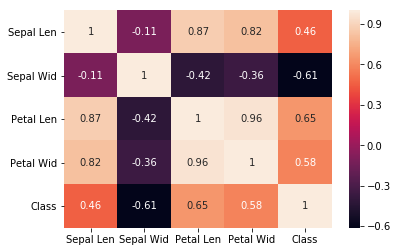

In [291]:
import seaborn as sns
sns.heatmap(correlataion,annot=True)

#All the independant variables have a very strong relation with the outcome variable(Class)
#No variable has a coorelation in the range of -0.1 to 0.1

## Question 5

*Observe the independent variables variance and drop such variables having no variance or almost zero variance(variance < 0.1). They will be having almost no influence on the classification.*

In [292]:
np.var(iris_data)

Sepal Len    0.681122
Sepal Wid    0.186751
Petal Len    3.092425
Petal Wid    0.578532
Class        0.666667
dtype: float64

In [293]:
#None of the independant variable variance is < 0.1. Hence all the variables have influence on the classification.

## Question 6

*Plot the scatter matrix for all the variables.*

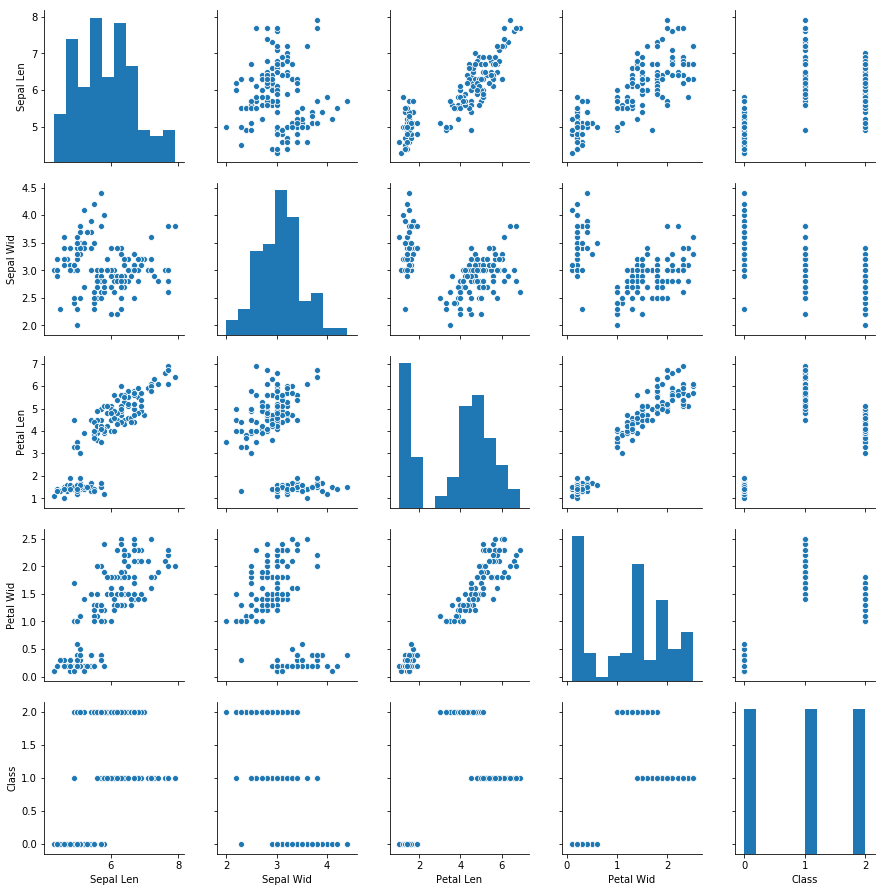

In [294]:
sns.pairplot(iris_data)

In [295]:
#If we obeserev the above plot, we see there is a linear relation between Petal Len and Petal Wid
#Clear classification of Class with Petal Len(which makes it having more influence)

## Split the dataset into training and test sets

## Question 7

*Split the dataset into training and test sets with 80-20 ratio.*

In [296]:
X = iris_data.drop("Class",axis=1)
y = iris_data['Class']

In [297]:
#taking 80:20 split on the data
#taken a random state value of 67 just ot get good variation in sample and the k value
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=67)

In [298]:
print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


In [299]:
#applying Z score as part of good practice to normalise the scaling.
#even though all the variables have the same scale.

from scipy.stats import zscore

X = X.apply(zscore)
X.sample(10)

,Sepal Len,Sepal Wid,Petal Len,Petal Wid
23,-0.900681,0.569251,-1.170675,-0.918558
61,0.068662,-0.124958,0.250967,0.396172
15,-0.173674,3.114684,-1.284407,-1.050031
114,-0.052506,-0.587764,0.762759,1.579429
59,-0.779513,-0.819166,0.080370,0.264699
149,0.068662,-0.124958,0.762759,0.790591
43,-1.021849,1.032057,-1.227541,-0.787085
72,0.553333,-1.281972,0.649027,0.396172
21,-0.900681,1.494863,-1.284407,-1.050031
106,-1.143017,-1.281972,0.421564,0.659118


## Question 8 - Model

*Build the model and train and test on training and test sets respectively using **scikit-learn**. Print the Accuracy of the model with different values of **k=3,5,9**.*

**Hint:** For accuracy you can check **accuracy_score()** in scikit-learn

In [300]:
#Creating a fuction by passing the value of K(3,5,9) as list and predicting its accuracy and error

from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

def KNNModel(neighbours):
    results_df = pd.DataFrame(index=["ModelAccuracyScore","MisClassificationError"])
    for n in neighbours:
        NNH = KNeighborsClassifier(n_neighbors=n)
        NNH.fit(X_train,y_train)
        y_predict = NNH.predict(X_test)
        score = metrics.accuracy_score(y_test,y_predict)
        mse   = 1 - score
        model_results = [score,mse]
        results_df[n] = model_results
    return results_df

In [302]:
neighbours = [3,5,9]
KNNModel(neighbours)

,3,5,9
ModelAccuracyScore,0.9,0.866667,0.933333
MisClassificationError,0.1,0.133333,0.066667


## Question 9 - Cross Validation

Run the KNN with no of neighbours to be 1,3,5..19 and *Find the **optimal number of neighbours** from the above list using the Mis classification error

Hint:

Misclassification error (MSE) = 1 - Test accuracy score. Calculated MSE for each model with neighbours = 1,3,5...19 and find the model with lowest MSE

In [303]:
#Passing the list to the same function created above as a list to display accuracy and mis classification error

k_list = [x for x in range(1,21) if x%2!=0]
model_results = KNNModel(k_list)
model_results

,1,3,5,7,9,11,13,15,17,19
ModelAccuracyScore,0.933333,0.9,0.866667,0.866667,0.933333,0.933333,0.933333,0.933333,0.933333,0.933333
MisClassificationError,0.066667,0.1,0.133333,0.133333,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667


In [304]:
#Looking at the above results misclassfication error is minimum for K = 1. If we choose K = 1 the model will be overfit.
#hence we choose K = 9 , where the accuracy is also good while the MSE is minimal.

## Question 10

*Plot misclassification error vs k (with k value on X-axis) using matplotlib.*

Text(0.5, 1.0, 'MSE vs k')

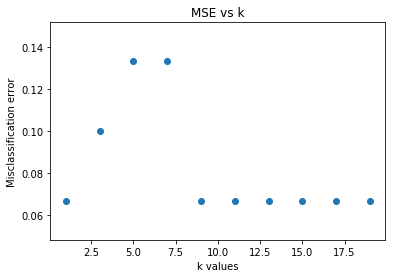

In [305]:
import matplotlib.pyplot as plt 
#plt.bar(k_val, MSE_val)

plt.scatter(k_list, model_results.loc['MisClassificationError'])
plt.xlabel('k values')
plt.ylabel('Misclassification error')
plt.title('MSE vs k')



# Naive Bayes with Iris Data

In [306]:
#Load all required library
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB

### Slice  Iris data set for Independent variables and dependent variables
#### Please note 'Species' is my dependent variables, name it y and independent set data as X

In [307]:
#the dependant variable name is 'Class' . Same is referrred below and in KNN. Hence keeping the same
#already assigned the X and y varibles above.Using the same.

In [310]:
#Check the dataset

X = iris_data.drop("Class",axis=1)
y = iris_data['Class']


In [311]:
print(y)
print(X)

0      0
1      0
2      0
3      0
4      0
5      0
6      0
7      0
8      0
9      0
10     0
11     0
12     0
13     0
14     0
15     0
16     0
17     0
18     0
19     0
20     0
21     0
22     0
23     0
24     0
25     0
26     0
27     0
28     0
29     0
      ..
120    1
121    1
122    1
123    1
124    1
125    1
126    1
127    1
128    1
129    1
130    1
131    1
132    1
133    1
134    1
135    1
136    1
137    1
138    1
139    1
140    1
141    1
142    1
143    1
144    1
145    1
146    1
147    1
148    1
149    1
Name: Class, Length: 150, dtype: int64
     Sepal Len  Sepal Wid  Petal Len  Petal Wid
0          5.1        3.5        1.4        0.2
1          4.9        3.0        1.4        0.2
2          4.7        3.2        1.3        0.2
3          4.6        3.1        1.5        0.2
4          5.0        3.6        1.4        0.2
5          5.4        3.9        1.7        0.4
6          4.6        3.4        1.4        0.3
7          5.0        3.4   

# Question 11 
Find the distribution of target variable (Class)

And, Plot the distribution of target variable using histogram

Class
0    [[AxesSubplot(0.125,0.551739;0.336957x0.328261...
1    [[AxesSubplot(0.125,0.551739;0.336957x0.328261...
2    [[AxesSubplot(0.125,0.551739;0.336957x0.328261...
dtype: object

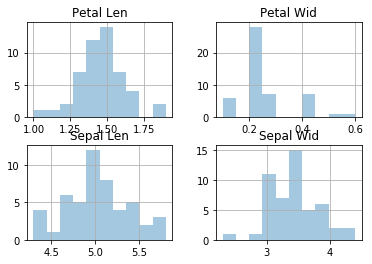

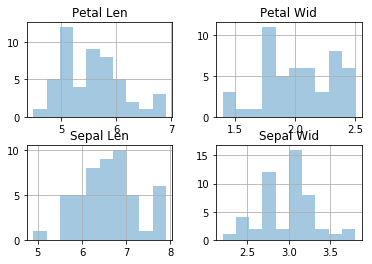

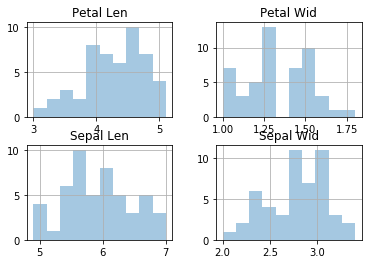

In [312]:
#Grouping the class variables into 0,1 and 2 and then plotting it for each variable

iris_data.groupby('Class').hist(alpha=0.4)

### Question 12 
Find Correlation among all variables and give your insights 

In [313]:
#Please note, it's Require to remove correlated features because they are voted twice in the model and 
## it can lead to over inflating importance.We will ignore it here

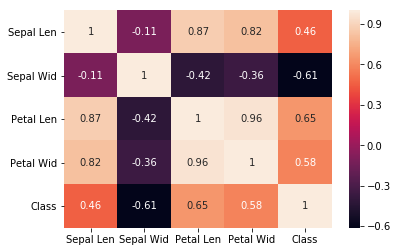

In [314]:
import seaborn as sns

corr = iris_data.corr()
sns.heatmap(corr,annot=True)

#All the independant variables have a very strong relation with the outcome variable(Class)
#No variable has a coorelation in the range of -0.1 to 0.1

### Split data in Training and test set in 80:20.

In [315]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=67)

print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


### Question 13 
Do Feature Scaling 

In [316]:
# Use StandardScaler or similar methods



# Standart scalar method was not taught in the residency!!!!!!!!!!!!

### Question 14 
Train and Fit NaiveBayes Model

In [317]:
#Fit the model
model = GaussianNB()
model.fit(X_train,y_train)
model

GaussianNB(priors=None, var_smoothing=1e-09)

In [318]:
#Predict
y_predict = model.predict(X_test)

### Question 15 
Print Accuracy and Confusion Matrix and Conclude your findings

In [325]:
# show Confusion Matrix
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score

cm = confusion_matrix(y_test,y_predict)
cm

array([[ 9,  0,  0],
       [ 0,  6,  0],
       [ 0,  1, 14]], dtype=int64)

In [320]:
# show accuracy
accuracy_score(y_test,y_predict)

0.9666666666666667

In [321]:
#Show precision and Recall metrics

#Micro :calculate metrics globally by counting the total true positives, false negatives and false positives.
precision_score(y_test,y_predict,average='micro')

0.9666666666666667

In [322]:
#macro :calculate metrics for each label, and find their unweighted mean. This does not take label imbalance into account.
precision_score(y_test,y_predict,average='macro')

0.9523809523809524

In [323]:
recall_score(y_test,y_predict,average='micro')

0.9666666666666667

In [329]:
recall_score(y_test,y_predict,average='macro')

0.9777777777777779

# For Practice  - Optional

All the questions from 16 to 20 are for practice.

# Using SVM with Diebetes Dataset

In [ ]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Question 16 
Read the input file 'Diabetes.csv' using Pandas and check it's column names.

Check dimension of dataset.

Check distribution of dependent variable, Outcome and plot it.


In [ ]:
# Eye ball the imported dataset

### Out of  768 data points, 500 are labeled as 0 and 268 as 1.
### Outcome 0 means No diabetes, outcome 1 means diabetes

In [ ]:
# Check data types and info of dataset

# Question 17 
Check data distribution using summary statistics and provide your findings.

Do correlation analysis and bivariate viualization with Insights


# Question 18 
Do train and test split. 
Optionally - You can do with stratify sampling(optional) on Outcome variable to maintain the distribution of dependent variable

# Question 19 
Train Support Vector Machine Model(1 Marks)

In [ ]:
# use from sklearn.svm import SVC

In [ ]:
# your insights

# Question 20
Scale the data points using MinMaxScaler

Fit SVM Model on Scale data and give your observation

#we can try increasing either C or gamma to fit a more complex model.

# Optional Question - 
Try improving the model accuracy using C=1000 (1 Marks)

### Here, increasing C allows us to improve the model, resulting in ??? accuracy.
### Let's try to explore different Kernel and C (Bonus for practice)

In [ ]:
import multiprocessing 
from sklearn.model_selection import GridSearchCV

In [ ]:
 param_grid = [    {        
     'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],        
     'C': [ 0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0 ]    } ]

In [ ]:
gs = GridSearchCV(estimator=SVC(), param_grid=param_grid,scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())

In [ ]:
gs.fit(X_train_scaled, y_train) 

In [ ]:
gs.best_estimator_

In [ ]:
gs.best_score_ 